# **1. Environment Setup & Global Configuration**

Installs necessary libraries, authenticates with Weights & Biases (W&B) for experiment tracking, and defines the global hyperparameter configuration using a Python standard Dataclass for strict typing and modularity.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from typing import Tuple, List, Dict, Optional
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
from torchmetrics.classification import MulticlassF1Score

import wandb
from kaggle_secrets import UserSecretsClient

In [2]:
# Authenticate W&B
try:
    user_secrets = UserSecretsClient()
    wandb_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=wandb_key)
    print("Logged into W&B successfully.")
except Exception as e:
    print(f"W&B login failed: {e}. Running in anonymous/offline mode.")

@dataclass
class SkinConfig:
    """Global configuration for the Skin Lesion Baseline Model."""
    seed: int = 42
    batch_size: int = 64
    max_epochs: int = 25
    lr: float = 1e-3
    image_size: Tuple[int, int] = (224, 224)
    num_classes: int = 7
    architecture: str = "MobileNetV3-Small"
    data_dir: str = "/kaggle/input/skin-cancer-mnist-ham10000"
    num_workers: int = 2

# Enforce reproducibility
pl.seed_everything(SkinConfig.seed)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wassamk44 (d4phoenix-ghostdev) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
Seed set to 42


Logged into W&B successfully.


42

# **2. Data Engineering & HAM10000 Metadata**

Loads the HAM10000 metadata CSV, maps the 7 skin lesion acronyms to human-readable integers, handles image file paths across the dataset directories, and performs stratified splitting (90/10) to maintain class distributions.

In [3]:
def process_metadata(config: SkinConfig) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[int, str], torch.Tensor]:
    print("Initializing Data Pipeline & Searching for files...")
    
    # 1. Automatically find the metadata file anywhere in Kaggle's input folder
    csv_path = None
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename == "HAM10000_metadata.csv":
                csv_path = os.path.join(dirname, filename)
                break
        if csv_path:
            break
            
    if csv_path is None:
        raise FileNotFoundError("Could not find HAM10000_metadata.csv. Please ensure the dataset is attached.")
        
    print(f"Success! Found metadata at: {csv_path}")
    df = pd.read_csv(csv_path)
    
    # 2. Automatically find ALL .jpg images anywhere in Kaggle's input folder
    image_paths = {}
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename.endswith('.jpg'):
                image_id = os.path.splitext(filename)[0]
                image_paths[image_id] = os.path.join(dirname, filename)
                
    df['path'] = df['image_id'].map(image_paths.get)
    
    # Drop rows where images weren't found
    df = df.dropna(subset=['path'])
    
    # 3. Class Mapping (The 7 Skin Lesion Types)
    lesion_type_dict = {
        'nv': 'Melanocytic nevi',
        'mel': 'Melanoma',
        'bkl': 'Benign keratosis-like lesions',
        'bcc': 'Basal cell carcinoma',
        'akiec': 'Actinic keratoses',
        'vasc': 'Vascular lesions',
        'df': 'Dermatofibroma'
    }
    
    # Convert string labels to categorical integers
    df['cell_type'] = df['dx'].map(lesion_type_dict)
    df['target'] = pd.Categorical(df['cell_type']).codes
    idx_to_class = dict(enumerate(pd.Categorical(df['cell_type']).categories))
    
    # 4. Compute Class Weights to handle severe class imbalance
    class_weights_arr = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(df['target']),
        y=df['target']
    )
    class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32)
    
    # 5. Stratified Split (90/10)
    train_df, val_df = train_test_split(
        df, test_size=0.1, stratify=df['target'], random_state=config.seed
    )
    
    print(f"Total Images Linked: {len(df)}")
    print(f"Training Samples: {len(train_df)} | Validation Samples: {len(val_df)}")
    
    return train_df, val_df, idx_to_class, class_weights_tensor

# Execute processing
train_df, val_df, CLASS_MAPPING, class_weights = process_metadata(SkinConfig())

Initializing Data Pipeline & Searching for files...
Success! Found metadata at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Total Images Linked: 10015
Training Samples: 9013 | Validation Samples: 1002


# **3. Custom Dataset & Lightning DataModule**

Defines an OOP-based PyTorch Dataset for loading images via PIL and applying torchvision transforms. Wraps the datasets in a PyTorch Lightning DataModule for seamless multi-GPU/worker scaling.

In [4]:
class HAM10000Dataset(Dataset):
    """Custom PyTorch Dataset for HAM10000 skin lesions."""
    def __init__(self, df: pd.DataFrame, transform: Optional[transforms.Compose] = None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = self.df.loc[idx, 'path']
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.df.loc[idx, 'target'], dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class SkinDataModule(pl.LightningDataModule):
    """PyTorch Lightning DataModule for data orchestration."""
    def __init__(self, train_df: pd.DataFrame, val_df: pd.DataFrame, config: SkinConfig):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.config = config
        
        # Training Augmentations
        self.train_transform = transforms.Compose([
            transforms.Resize(self.config.image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Validation Transforms
        self.val_transform = transforms.Compose([
            transforms.Resize(self.config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def setup(self, stage: Optional[str] = None):
        self.train_dataset = HAM10000Dataset(self.train_df, transform=self.train_transform)
        self.val_dataset = HAM10000Dataset(self.val_df, transform=self.val_transform)

    def train_dataloader(self) -> DataLoader:
        return DataLoader(self.train_dataset, batch_size=self.config.batch_size,
                          shuffle=True, num_workers=self.config.num_workers, pin_memory=True)

    def val_dataloader(self) -> DataLoader:
        return DataLoader(self.val_dataset, batch_size=self.config.batch_size,
                          shuffle=False, num_workers=self.config.num_workers, pin_memory=True)

data_module = SkinDataModule(train_df, val_df, SkinConfig())

# **4. MediScanX Skin Baseline: MobileNetV3-Small**

Constructs the baseline classification engine. Utilizes a pre-trained MobileNetV3-Small from torchvision, modifying the classifier head. Implements PyTorch Lightning's structural loops and utilizes weighted cross-entropy to handle dataset imbalance.

In [5]:
class MediScanX_Skin_Baseline(pl.LightningModule):
    """MobileNetV3-Small implementation optimized for edge inference."""
    def __init__(self, config: SkinConfig, class_weights: torch.Tensor):
        super().__init__()
        # Ignore class_weights in hyperparameters so it doesn't crash W&B logging
        self.save_hyperparameters(ignore=['class_weights'])
        self.config = config
        
        # 1. Load Pre-trained MobileNetV3-Small
        self.model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        
        # 2. Modify Classifier Head for our 7 classes
        in_features = self.model.classifier[3].in_features
        self.model.classifier[3] = nn.Linear(in_features, self.config.num_classes)
        
        # 3. Define Loss & Metrics
        # Weighted loss prevents the model from ignoring rare skin cancers
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        # Using Macro F1 exactly like the ECG model
        self.train_f1 = MulticlassF1Score(num_classes=self.config.num_classes, average='macro')
        self.val_f1 = MulticlassF1Score(num_classes=self.config.num_classes, average='macro')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def training_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_f1(logits, y)
        
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1", self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_f1(logits, y)
        
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_f1", self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # AdamW optimizer with a learning rate scheduler to fine-tune as it learns
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.config.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
        )
        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_loss"}

# Initialize the model and load it into memory
model = MediScanX_Skin_Baseline(SkinConfig(), class_weights)
print("MobileNetV3-Small initialized successfully.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 77.1MB/s]

MobileNetV3-Small initialized successfully.


# **5. Model Training & W&B Tracking**

Initializes the PyTorch Lightning Trainer with EarlyStopping and ModelCheckpointing. Executes the training loop while streaming metrics to the cloud to ensure the model stops before overfitting.

In [6]:
config = SkinConfig()

# 1. Initialize Loggers and Callbacks
wandb_logger = WandbLogger(project="MediScanX-Skin-Baseline", name="MobileNetV3-Small")

# The tripwire: stop training if it doesn't improve for 5 epochs
early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    verbose=True, 
    mode="min"
)

# The save state: only keep the absolute best model
checkpoint_callback = ModelCheckpoint(
    dirpath="models/",
    filename="mediscanx-skin-best-{epoch:02d}-{val_loss:.3f}",
    save_top_k=1,
    verbose=True,
    monitor="val_loss",
    mode="min"
)

# 2. Initialize Trainer
trainer = pl.Trainer(
    max_epochs=config.max_epochs,
    logger=wandb_logger,
    callbacks=[early_stop_callback, checkpoint_callback],
    accelerator="auto", 
    devices=1,
    precision="16-mixed" # Uses 16-bit math to double training speed on Kaggle GPUs
)

# 3. Execute Training
print("Beginning Training Pipeline...")
trainer.fit(model, datamodule=data_module)

# Close the W&B connection when done
wandb.finish()
print("Training Complete. Best model saved to /models/")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Beginning Training Pipeline...


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3       │  1.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ train_f1  │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ val_f1    │ MulticlassF1Score │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Metric val_loss improved. New best score: 1.571
Epoch 0, global step 141: 'val_loss' reached 1.57078 (best 1.57078), saving model to '/kaggle/working/models/mediscanx-skin-best-epoch=00-val_loss=1.571.ckpt' as top 1
Metric val_loss improved by 0.657 >= min_delta = 0.0. New best score: 0.914
Epoch 1, global step 282: 'val_loss' reached 0.91355 (best 0.91355), saving model to '/kaggle/working/models/mediscanx-skin-best-epoch=01-val_loss=0.914.ckpt' as top 1
Metric val_loss improved by 0.076 >= min_delta = 0.0. New best score: 0.837
Epoch 2, global step 423: 'val_loss' reached 0.83746 (best 0.83746), saving model to '/kaggle/working/models/mediscanx-skin-best-epoch=02-val_loss=0.837.ckpt' as top 1
Epoch 3, global step 564: 'val_loss' was not in top 1
Metric val_loss improved by 0.098 >= min_delta = 0.0. New best score: 0.740
Epoch 4, global step 705: 'val_loss' reached 0.73979 (best 0.73979), saving model to '/kaggle/working/models/mediscanx-skin-best-epoch=04-val_loss=0.740.ckpt' as top 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_f1,▁▃▃▄▄▄▅▅▅▅▅▆▅▆▇▇▇▇▇██
train_loss,█▆▅▅▅▄▄▃▃▄▃▃▃▃▂▂▂▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
val_f1,▂▁▃▂▄▄▅▆▅▁▆▅▄▅▇▇▇▇███
val_loss,█▄▃▃▂▂▃▃▂▄▁▃▂▃▂▁▂▂▂▂▂
epoch,20
train_f1,0.89476
train_loss,0.15392
trainer/global_step,2960
val_f1,0.80835


Training Complete. Best model saved to /models/


# **6. Clinical Evaluation & Grad-CAM Visualizations**

Loads the mathematically optimal checkpoint saved by EarlyStopping. Evaluates the validation set to plot the 7x7 confusion matrix. Implements a Grad-CAM hook into MobileNetV3's final convolutional layer to generate clinical heatmaps, fulfilling the Explainable AI (XAI) requirement of MediScanX.

Loading optimal weights from: /kaggle/working/models/mediscanx-skin-best-epoch=15-val_loss=0.547.ckpt
Evaluating validation set...


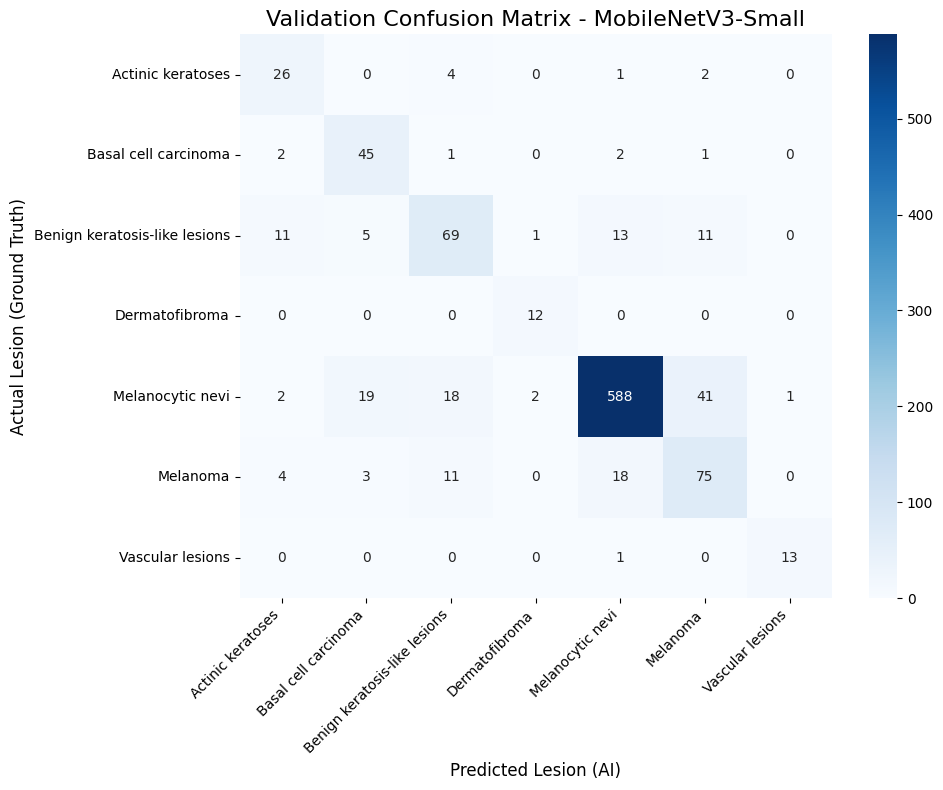

In [9]:
import cv2
import torch
from torch.serialization import add_safe_globals

# 1. NEW SECURITY FIX: Tell PyTorch 2.6 that our custom class is safe to load
add_safe_globals([SkinConfig])

# 2. Load the absolute best model saved by the Early Stopper
best_model_path = checkpoint_callback.best_model_path
print(f"Loading optimal weights from: {best_model_path}")

eval_model = MediScanX_Skin_Baseline.load_from_checkpoint(
    best_model_path, 
    config=config, 
    class_weights=class_weights
)
eval_model.eval()
eval_model.to("cuda" if torch.cuda.is_available() else "cpu")

# 3. Generate Predictions for Confusion Matrix
all_preds = []
all_targets = []
val_loader = data_module.val_dataloader()

print("Evaluating validation set...")
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(eval_model.device)
        logits = eval_model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y.numpy())

# Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASS_MAPPING[i] for i in range(7)], 
            yticklabels=[CLASS_MAPPING[i] for i in range(7)])
plt.title('Validation Confusion Matrix - MobileNetV3-Small', fontsize=16)
plt.ylabel('Actual Lesion (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Lesion (AI)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Generating Grad-CAM Heatmap for XAI Proof...


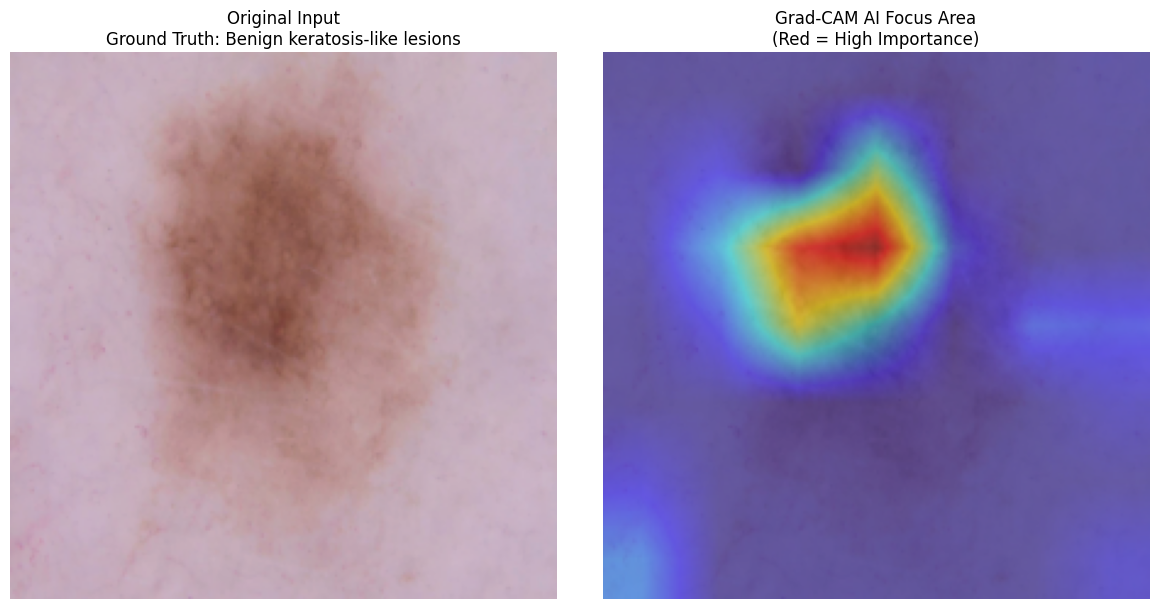

In [10]:
# 4. Lightweight Grad-CAM implementation for MobileNetV3
class MobileNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        # Hook into the very last convolutional block before the pooling/classifier
        target_layer = self.model.model.features[-1]
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx):
        # Ensure gradients are enabled for Grad-CAM math
        old_state = torch.is_grad_enabled()
        torch.set_grad_enabled(True)
        
        logits = self.model(x)
        self.model.zero_grad()
        
        # Target the specific class prediction
        loss = logits[0, class_idx]
        loss.backward()
        
        # Weight the activations by the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(self.activations, dim=1).squeeze().cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0) # Apply ReLU
        heatmap /= np.max(heatmap) + 1e-8 # Normalize between 0 and 1
        
        torch.set_grad_enabled(old_state) # Restore previous grad state
        return heatmap

# 5. Generate and display a sample heatmap
# Grab the first batch of images from the final exam
sample_imgs, sample_labels = next(iter(val_loader))

# Take the first image in the batch
sample_img = sample_imgs[0]
sample_label = sample_labels[0]
sample_tensor = sample_img.unsqueeze(0).to(eval_model.device).requires_grad_(True)

print("\nGenerating Grad-CAM Heatmap for XAI Proof...")
cam_generator = MobileNetGradCAM(eval_model)
heatmap = cam_generator(sample_tensor, sample_label.item())

# Formatting the image for visual display (un-normalizing)
img_display = sample_img.permute(1, 2, 0).numpy()
img_display = (img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

# Apply the heat colors
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = np.float32(heatmap_colored) / 255
heatmap_colored = heatmap_colored[:, :, ::-1] # Convert BGR to RGB
overlay = heatmap_colored * 0.5 + img_display * 0.5

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_display)
axes[0].set_title(f"Original Input\nGround Truth: {CLASS_MAPPING[sample_label.item()]}")
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title("Grad-CAM AI Focus Area\n(Red = High Importance)")
axes[1].axis('off')

plt.tight_layout()
plt.show()